<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/LSST_Candidates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
%%capture
!pip install alerce
!pip install pyvo

In [4]:
from alerce.core import Alerce
import pyvo as vo

In [34]:
alerce_client = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [6]:
tid = 1

In [47]:
n_objs = 50
n_det_min = 5
classifier_id = 1
class_id = 0 # SN

query = '''
SELECT TOP %d
    obj.*,
    prob.*
FROM
    alerce_tap.object AS obj
JOIN
    alerce_tap.probability AS prob
ON
    obj.oid = prob.oid
    AND obj.sid = prob.sid
WHERE
    obj.n_det >= %d
    AND prob.classifier_id = %d
    AND prob.class_id = %d
    AND prob.ranking = 1
ORDER BY prob.probability DESC
''' % (n_objs, n_det_min,
       classifier_id, class_id)
df_objs = alerce_tap.search(query).to_table().to_pandas()

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=cols, inplace=True)

In [48]:
df_objs

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date,classifier_id,classifier_version,class_id,probability,ranking
0,313765480543813793,1,1,60.558698,-49.059296,1.171559e-05,1.301392e-05,61004.301777,61095.089168,90.787391,20,190,0,2026-02-13,2026-02-24,1,201,0,0.997090,1
1,313897383918305299,1,1,64.638420,-47.093869,8.522741e-05,6.399082e-05,61034.161304,61095.065497,60.904193,8,144,0,2026-02-13,2026-02-24,1,201,0,0.996883,1
2,170032924022800424,1,1,186.228824,7.444803,4.080487e-06,3.929570e-06,61090.251692,61095.215152,4.963460,17,173,0,2026-02-20,2026-02-24,1,201,0,0.996842,1
3,313765480549056772,1,1,60.072809,-48.814756,3.249908e-05,3.951998e-05,61004.301777,61095.053670,90.751892,6,144,0,2026-02-13,2026-02-24,1,201,0,0.996801,1
4,313897384074018915,1,1,63.588264,-47.710480,1.767983e-05,1.785153e-05,61034.161767,61094.112531,59.950765,10,119,0,2026-02-13,2026-02-24,1,201,0,0.996777,1
5,313897384103379107,1,1,63.960148,-48.973827,2.329036e-05,2.255245e-05,61034.161767,61095.088734,60.926967,15,149,0,2026-02-13,2026-02-24,1,201,0,0.996365,1
6,313893023122980956,1,1,62.081009,-46.931759,2.830006e-07,2.768487e-07,61033.284793,61095.094861,61.810069,150,184,0,2026-02-13,2026-02-24,1,201,0,0.995795,1
7,170028528485531717,1,1,186.694653,7.918190,7.304178e-07,7.458321e-07,61090.256338,61095.209479,4.953141,47,267,0,2026-02-20,2026-02-24,1,201,0,0.995770,1
8,170028528365993996,1,1,186.196046,7.352936,1.413576e-05,1.488181e-05,61090.251692,61095.192963,4.941271,23,230,0,2026-02-20,2026-02-24,1,201,0,0.995550,1
9,170028526873870371,1,1,186.808234,8.482416,6.333561e-08,6.659057e-08,61090.249392,61098.241373,7.991980,457,464,0,2026-02-19,2026-02-27,1,201,0,0.995368,1


In [49]:
sid = 1
query = """
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.sid = %d
    AND lsst_det.oid IN (%s)
""" % (sid, ','.join(map(str, df_objs.oid.values)))
df_aux = alerce_tap.search(query).to_table().to_pandas()

In [50]:
df_aux.columns

Index(['oid', 'sid', 'measurement_id', 'mjd', 'ra', 'dec', 'band',
       'created_date', 'oid_', 'sid_',
       ...
       'pixelflags_suspectcenter', 'pixelflags_streak',
       'pixelflags_streakcenter', 'pixelflags_injected',
       'pixelflags_injectedcenter', 'pixelflags_injected_template',
       'pixelflags_injected_templatecenter', 'glint_trail', 'has_stamp',
       'created_date_'],
      dtype='object', length=106)

In [27]:
#df_aux = df_aux[['oid','mjd', 'band', 'psfflux', 'psffluxerr', 'scienceflux', 'sciencefluxerr']]

In [28]:
df_aux

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,oid_,sid_,...,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,created_date_
0,170028526873870371,1,170028526873870371,61090.249392,186.808237,8.482422,3,2026-02-19,170028526873870371,1,...,False,False,False,False,False,False,False,False,False,2026-02-19
1,170028526873870371,1,170028527011233859,61090.249860,186.808235,8.482416,3,2026-02-19,170028526873870371,1,...,False,False,False,False,False,False,False,False,False,2026-02-19
2,170028526873870371,1,170028527143878711,61090.250327,186.808233,8.482417,3,2026-02-23,170028526873870371,1,...,False,False,False,False,False,False,False,False,False,2026-02-23
3,170028526873870371,1,170028527279669269,61090.250794,186.808239,8.482420,3,2026-02-19,170028526873870371,1,...,False,False,False,False,False,False,False,False,False,2026-02-19
4,170028526873870371,1,170028527413887018,61090.251227,186.808235,8.482417,3,2026-02-19,170028526873870371,1,...,False,False,False,False,False,False,False,False,False,2026-02-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,313897384103379107,1,170046089236316296,61094.115994,63.960172,-48.973792,2,2026-02-23,313897384103379107,1,...,False,False,False,False,False,False,False,False,True,2026-02-23
749,313897384103379107,1,170050472658337968,61095.041993,63.960399,-48.973800,3,2026-02-24,313897384103379107,1,...,False,False,False,False,False,False,False,False,True,2026-02-24
750,313897384103379107,1,170050483927384269,61095.083331,63.960020,-48.973716,2,2026-02-24,313897384103379107,1,...,False,False,False,False,False,False,False,False,True,2026-02-24
751,313897384103379107,1,170050485538521280,61095.088734,63.959979,-48.973963,2,2026-02-24,313897384103379107,1,...,False,False,False,False,False,False,False,False,True,2026-02-24


In [29]:
df_aux.oid.nunique()

10

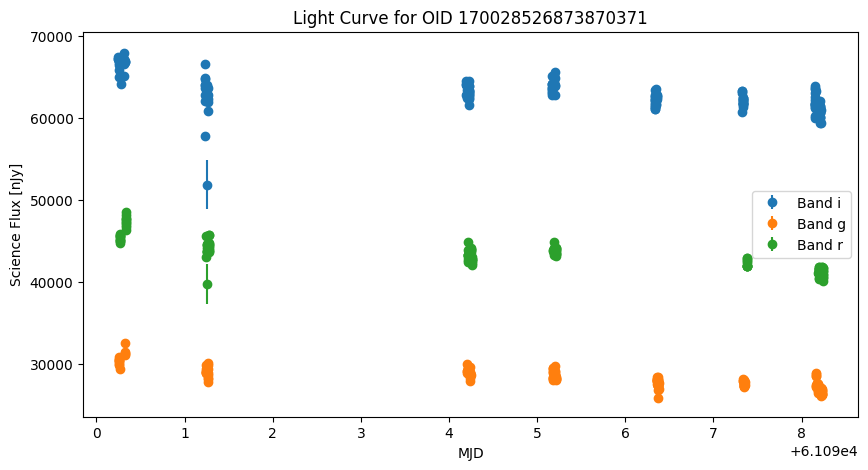

In [30]:
band_map = {
    6: 'u',
    1: 'g',
    2: 'r',
    3: 'i',
    4: 'z',
    5: 'y',
}

for oid in df_aux.oid.unique():
    df_oid = df_aux[df_aux.oid == oid].copy()
    bands = df_oid.band.unique()

    fig, ax = plt.subplots(figsize=(10, 5))
    for band in bands:
        subset = df_oid[df_oid.band == band]
        ax.errorbar(
            subset.mjd,
            subset.scienceflux,
            yerr=subset.sciencefluxerr,
            fmt='o',
            label=f'Band {band_map[band]}',
        )

    ax.set_title(f'Light Curve for OID {oid}')
    ax.set_xlabel('MJD')
    ax.set_ylabel(r'Science Flux [nJy]')
    ax.legend()
    plt.show()

    break

In [51]:
all_df_obj_ztf = pd.DataFrame()
for oid in df_aux.oid.unique():
    df_oid = df_aux[df_aux.oid == oid].copy()
    ra, dec = df_oid.ra.values[0], df_oid.dec.values[0]

    df_obj_ztf = alerce_client.query_objects(
    survey='ztf',
    ra=ra,
    dec=dec,
    radius=1.5,
    )

    if df_obj_ztf.size > 0:
        all_df_obj_ztf = pd.concat([all_df_obj_ztf, df_obj_ztf])
        print(oid,ra,dec, df_obj_ztf.size)


170028526579744777 185.0201369704093 7.815302857155211 23
170028527303262373 187.40437224924472 7.932741500186298 23
170028528508600371 187.40403138804328 7.932887753786043 23
170028536459427886 187.40415836902264 7.932889964383911 23
170028538061652034 187.07789063231013 8.72932180477633 23


In [52]:
df_obj_ztf

""
